# Document Clustering — Exploratory Data Analysis

We work with the **20 Newsgroups** text corpus, restricted to six categories. This notebook explores document lengths, vocabulary, and per-category word usage before any modelling.

## 1. Imports & Fetch Data

We import all standard libraries and load the six-category newsgroups data via `utils.load_newsgroups`. No labels are used for training — they exist only as reference for evaluation later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import sys, os
sys.path.insert(0, '.')
from utils import load_newsgroups
sns.set_style('whitegrid')
%matplotlib inline

CATEGORIES = [
    'rec.sport.hockey',
    'sci.space',
    'talk.politics.mideast',
    'comp.graphics',
    'rec.autos',
    'sci.med',
]
df = load_newsgroups(CATEGORIES)
print('Shape:', df.shape)
df.head()

Shape: (5879, 2)


,text,true_category
0,This is such Bullshit. Deir Yassin was an unp...,talk.politics.mideast
1,"Check out the shocks where they mount,...",rec.autos
2,"While in grad school, I remember a biochemistr...",sci.med
3,From: Center for Policy Research <cpr>\nSubjec...,talk.politics.mideast
4,\nIt seems sad that people lose all perspectiv...,rec.autos


## 2. Dataset Overview

We inspect basic dataset properties: total document count, category balance, and a quick look at the first few raw texts. A balanced distribution across categories is desirable — it keeps cluster evaluation fair.

In [2]:
print('Total documents:', len(df))
print('\nDocuments per category:')
print(df['true_category'].value_counts())
print('\nNull values:', df.isnull().sum().sum())
print('\nEmpty docs (empty string):', (df['text'].str.strip() == '').sum())

Total documents: 5879

Documents per category:


true_category
rec.sport.hockey         999
rec.autos                990
sci.med                  990
sci.space                987
comp.graphics            973
talk.politics.mideast    940
Name: count, dtype: int64

Null values: 0



Empty docs (empty string): 178


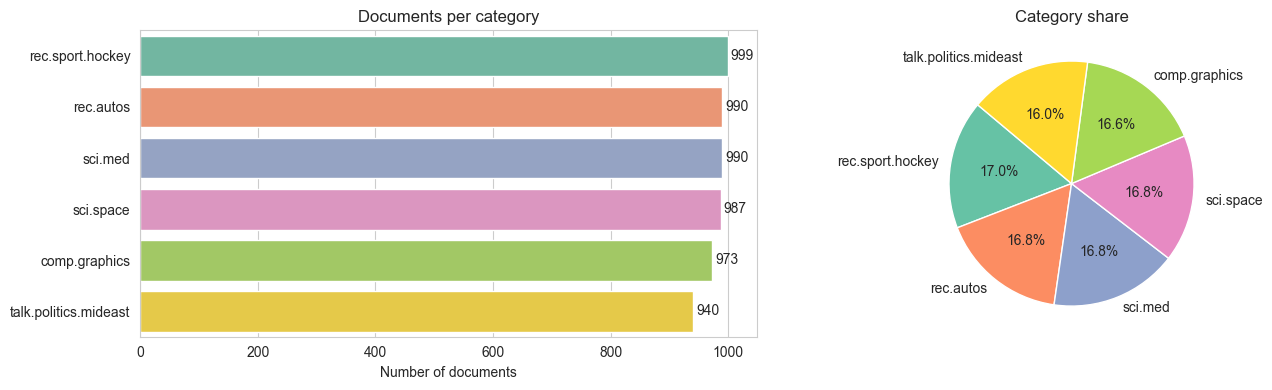

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
counts = df['true_category'].value_counts()
# Countplot
sns.barplot(x=counts.values, y=counts.index, ax=axes[0], palette='Set2')
axes[0].set_xlabel('Number of documents'); axes[0].set_ylabel('')
axes[0].set_title('Documents per category')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10)
# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(counts)), startangle=140)
axes[1].set_title('Category share')
plt.tight_layout(); plt.show()

## 3. Document Length Analysis

Document length varies widely across newsgroup posts. Very short documents may be noise; very long ones may distort TF-IDF vectors. We examine both character-level and word-level lengths, then break them down by category.

In [4]:
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
print(df[['char_count', 'word_count']].describe().round(1))

       char_count  word_count
count      5879.0      5879.0
mean       1283.2       205.1
std        3860.1       593.3
min           0.0         0.0
25%         241.0        41.0
50%         494.0        84.0
75%        1034.0       173.0
max       74878.0     11251.0


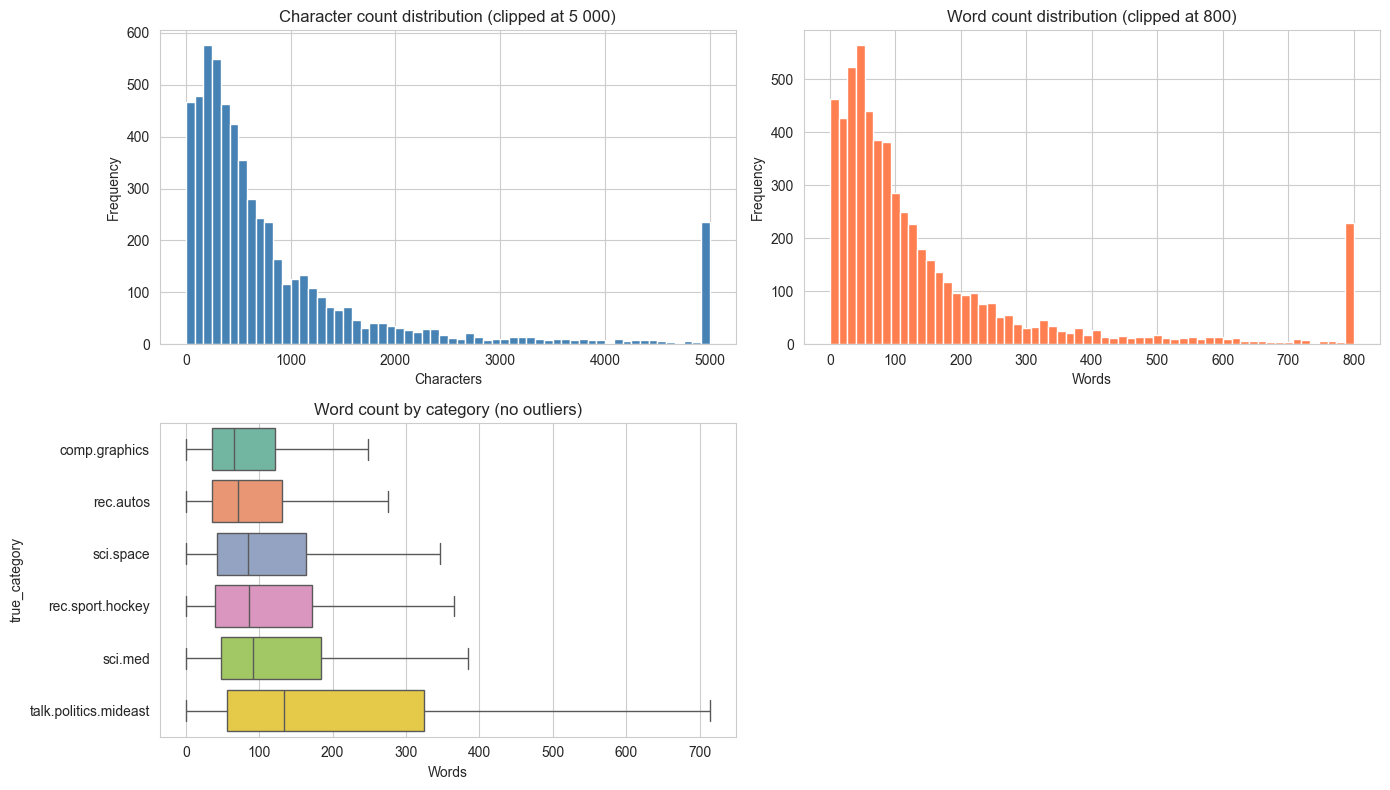

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
# Overall char count
axes[0, 0].hist(df['char_count'].clip(upper=5000), bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Character count distribution (clipped at 5 000)')
axes[0, 0].set_xlabel('Characters'); axes[0, 0].set_ylabel('Frequency')
# Overall word count
axes[0, 1].hist(df['word_count'].clip(upper=800), bins=60, color='coral', edgecolor='white')
axes[0, 1].set_title('Word count distribution (clipped at 800)')
axes[0, 1].set_xlabel('Words'); axes[0, 1].set_ylabel('Frequency')
# Box plots by category
order = df.groupby('true_category')['word_count'].median().sort_values().index
sns.boxplot(data=df, x='word_count', y='true_category', order=order,
            palette='Set2', ax=axes[1, 0], showfliers=False)
axes[1, 0].set_title('Word count by category (no outliers)'); axes[1, 0].set_xlabel('Words')
axes[1, 1].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Most Frequent Words (Corpus-Wide)

After removing standard English stop-words we chart the 30 most common words in the entire corpus. Dominant words like *game*, *space*, *car* already hint at the underlying topic structure.

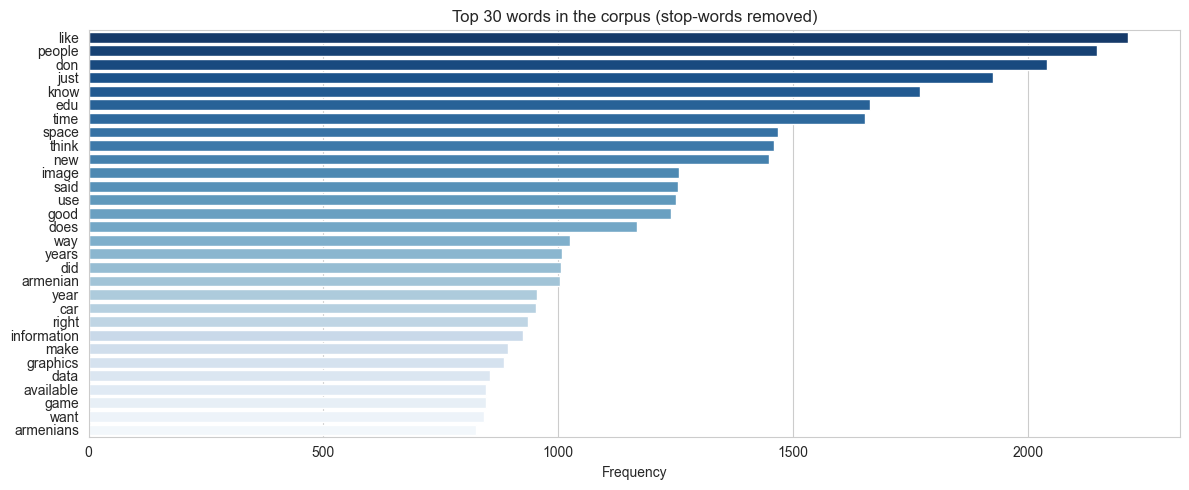

In [6]:
import re
stop = ENGLISH_STOP_WORDS
all_words = []
for text in df['text']:
    tokens = re.findall(r'[a-z]+', text.lower())
    all_words.extend([t for t in tokens if t not in stop and len(t) > 2])
counter = Counter(all_words)
top30 = pd.DataFrame(counter.most_common(30), columns=['word', 'count'])
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top30, x='count', y='word', palette='Blues_r', ax=ax)
ax.set_title('Top 30 words in the corpus (stop-words removed)')
ax.set_xlabel('Frequency'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

## 5. Word Clouds per Category

A word cloud for each of the six categories reveals the characteristic vocabulary used in each newsgroup. Topics that cluster cleanly (e.g. *sci.space*, *rec.sport.hockey*) tend to have a concentrated, distinctive vocabulary.

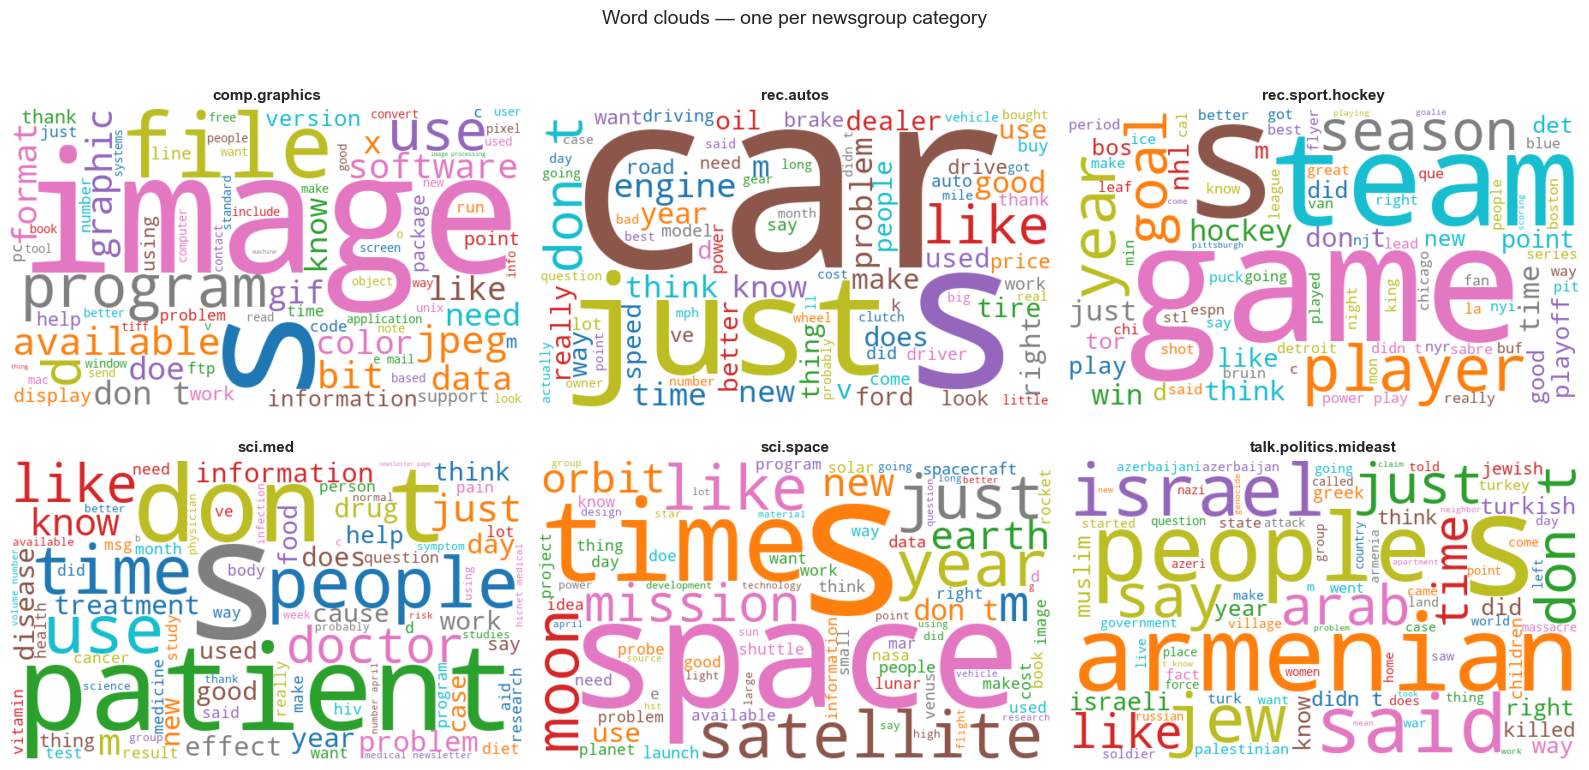

In [7]:
import re as _re
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, cat in enumerate(sorted(df['true_category'].unique())):
    corpus = ' '.join(df[df['true_category'] == cat]['text'])
    corpus = _re.sub(r'[^a-z\s]', ' ', corpus.lower())
    wc = WordCloud(width=600, height=350, background_color='white',
                   stopwords=stop, max_words=80, colormap='tab10').generate(corpus)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(cat, fontsize=11, fontweight='bold')
plt.suptitle('Word clouds — one per newsgroup category', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 6. Sample Documents per Category

Reading real posts helps build intuition about tone, length, and vocabulary. Two representative documents are shown for each category — headers, footers, and quoted replies have already been stripped by the dataset loader.

In [8]:
for cat in sorted(df['true_category'].unique()):
    subset = df[df['true_category'] == cat]
    print(f'\n{'='*60}')
    print(f'Category: {cat}')
    print(f'{'='*60}')
    for _, row in subset.sample(2, random_state=42).iterrows():
        preview = row['text'][:400].replace('\n', ' ')
        print(f'[{row["word_count"]} words] {preview}...')
        print()


Category: comp.graphics


[55 words] I recently read in a book that the TIFF version 6.0 specification was due to be released in the spring of 1992.  I am interested in finding out about the new features of the TIFF spec (and if it is out).  Specifically, I need to know if TIFF 6.0 supports VQ decompression and/or image tiling. ...

[30 words]    Does anybody have a collection of occurances of 42? (before and after The Guide). If not, I would like to receive any odd bits you might know. postings to alt.fan.douglas.adams.  ...


Category: rec.autos
[35 words] I have a 1982 Regal and I am interested in buying a fiberglass hood, trunk, and bumpers for it.  Does anybody know of a company who makes fiberglass parts for Regals ??   		Thanks in advance, ...

[56 words]     	Wasn't the original intent of the reverse lights for the driver, so he could see where he was backing up???  Although reverse lights on the sides are useful for telling whether cars are backing up out perpendicular to the path of the car, I don't t


Category: rec.sport.hockey
[128 words] I live in the desolate MidWest (as far as hockey is concerned) and our "sports" stores around here carry VERY LITTLE hockey stuff, except for San Jose, Tampa Bay, L.A., Pittsburgh, and if you're lucky Chicago.  I would like to know if anyone knows of any m,ail order, phone order stores that I might be able to get in contact with.  I am dying for some real hockey stuff (hats, shirts, key chains, et...

[170 words]   About 25 is correct for Numminen and Lumme.    No, Kurri's points are too low. 27 for Kurri and 28 for Sel{nne.     That's true. Game is so different here in Europe compared to NHL. North-ame- ricans are better in small rinks and europeans in large rinks. An average european player from Sweden, Finland, Russian or Tsech/Slovakia is a better  skater and  puckhandler than his NHL colleague. Especi...




Category: sci.med
[49 words] can anyone give me more information regarding endometriosis?   i heard it's a very common disease among women and if anyone can provide names of a specialist/surgeon in  the north carolina research triangle  park area (raleigh/durham/chapel  hill) who is familiar with the condition, i would really appreciate it.  thanks.   --Naomi...

[190 words] -*----  I do not have enough medical expertise to have much of an opinion one way or another on hidden candida infections.  I can understand the skepticism of those who see this associated with various general kinds of symptoms, while there is a lack of solid demonstration that this happens and causes such general symptoms. (To understand this skepticism, one only needs to know of past failures th...


Category: sci.space
[35 words]  There was a recession, and none of the potential entrants could raise any money.  The race organizers were actually supposed to be handling part of the fundraising, but the less said 


Category: talk.politics.mideast
[53 words]   Hehehe.  BTW, does the Litani River not flow West and not South? I think that its waters stay entirely within Lebanese territory and so what Hasan says about the Jordan River makes no sense, in any case. The Hasbani River, on the other hand, flows into the Jordan, if I am not mistaken....

[69 words]    	I disagree.  By converting to another religion, you certainly do change your cultural identity, and lose that part of you which was Jewish.     	No, there is a serious cultural and religios difference between renouncing the jewish god and accepting a new one.  "Thou shall have no other gods before me."  Conversion is a violation of this, atheism you might be able to wiggle around with.  Adam  ...



## 7. Summary of Key Findings

The table below consolidates per-category statistics gathered in this notebook. Categories with a large vocabulary spread and longer documents tend to be harder to separate during clustering.

In [9]:
summary = df.groupby('true_category').agg(
    doc_count=('text', 'count'),
    mean_words=('word_count', 'mean'),
    median_words=('word_count', 'median'),
    std_words=('word_count', 'std'),
    mean_chars=('char_count', 'mean'),
).round(1)
summary

,doc_count,mean_words,median_words,std_words,mean_chars
true_category,,,,,
comp.graphics,973,196.8,65.0,811.7,1294.3
rec.autos,990,113.1,71.0,216.9,655.2
rec.sport.hockey,999,184.6,86.0,494.6,1125.8
sci.med,990,200.1,92.0,467.6,1309.6
sci.space,987,189.9,85.0,495.9,1212.7
talk.politics.mideast,940,353.7,134.0,831.7,2146.4
